In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
import matplotlib.pyplot as plt

from transformers import AutoTokenizer

from src.data_loader import load_train_reviews

In [3]:
train_df = load_train_reviews()
train_df.shape

d:\Quera\Exercises\amazon-review-sentiment-analysis\src\data_loader.py:17: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


(838944, 11)

In [4]:
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [5]:
text = train_df.loc[0, "reviewText"]
print(text)

tokens = tokenizer.tokenize(text)
tokens[:100]

I have an older URC-WR7 remote and thought this would be an upgrade (and because TWC stuck me with it), but this one fails where the other one didn't.  The old remote could go head to head and learn.  I have 2 different Blu Ray players (LG & Panasonic) and this one fails on both.  It cannot learn buttons.  The biggest problem is in streaming when I need to hit the blue, red, yellow, green buttons.  These cannot work either of them, so I have to pull out the remote for that one setting.  I don't know why they give you multiple code methods but no learning.


['i',
 'have',
 'an',
 'older',
 'ur',
 '##c',
 '-',
 'wr',
 '##7',
 'remote',
 'and',
 'thought',
 'this',
 'would',
 'be',
 'an',
 'upgrade',
 '(',
 'and',
 'because',
 't',
 '##wc',
 'stuck',
 'me',
 'with',
 'it',
 ')',
 ',',
 'but',
 'this',
 'one',
 'fails',
 'where',
 'the',
 'other',
 'one',
 'didn',
 "'",
 't',
 '.',
 'the',
 'old',
 'remote',
 'could',
 'go',
 'head',
 'to',
 'head',
 'and',
 'learn',
 '.',
 'i',
 'have',
 '2',
 'different',
 'blu',
 'ray',
 'players',
 '(',
 'l',
 '##g',
 '&',
 'pan',
 '##as',
 '##onic',
 ')',
 'and',
 'this',
 'one',
 'fails',
 'on',
 'both',
 '.',
 'it',
 'cannot',
 'learn',
 'buttons',
 '.',
 'the',
 'biggest',
 'problem',
 'is',
 'in',
 'streaming',
 'when',
 'i',
 'need',
 'to',
 'hit',
 'the',
 'blue',
 ',',
 'red',
 ',',
 'yellow',
 ',',
 'green',
 'buttons',
 '.',
 'these']

In [6]:
ids = tokenizer.convert_tokens_to_ids(tokens)
ids[:30]

[1045,
 2031,
 2019,
 3080,
 24471,
 2278,
 1011,
 23277,
 2581,
 6556,
 1998,
 2245,
 2023,
 2052,
 2022,
 2019,
 12200,
 1006,
 1998,
 2138,
 1056,
 16526,
 5881,
 2033,
 2007,
 2009,
 1007,
 1010,
 2021,
 2023]

In [7]:
encoding = tokenizer(text)
encoding.keys()

KeysView({'input_ids': [101, 1045, 2031, 2019, 3080, 24471, 2278, 1011, 23277, 2581, 6556, 1998, 2245, 2023, 2052, 2022, 2019, 12200, 1006, 1998, 2138, 1056, 16526, 5881, 2033, 2007, 2009, 1007, 1010, 2021, 2023, 2028, 11896, 2073, 1996, 2060, 2028, 2134, 1005, 1056, 1012, 1996, 2214, 6556, 2071, 2175, 2132, 2000, 2132, 1998, 4553, 1012, 1045, 2031, 1016, 2367, 14154, 4097, 2867, 1006, 1048, 2290, 1004, 6090, 3022, 12356, 1007, 1998, 2023, 2028, 11896, 2006, 2119, 1012, 2009, 3685, 4553, 11287, 1012, 1996, 5221, 3291, 2003, 1999, 11058, 2043, 1045, 2342, 2000, 2718, 1996, 2630, 1010, 2417, 1010, 3756, 1010, 2665, 11287, 1012, 2122, 3685, 2147, 2593, 1997, 2068, 1010, 2061, 1045, 2031, 2000, 4139, 2041, 1996, 6556, 2005, 2008, 2028, 4292, 1012, 1045, 2123, 1005, 1056, 2113, 2339, 2027, 2507, 2017, 3674, 3642, 4725, 2021, 2053, 4083, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [8]:
encoding["input_ids"][:30]

[101,
 1045,
 2031,
 2019,
 3080,
 24471,
 2278,
 1011,
 23277,
 2581,
 6556,
 1998,
 2245,
 2023,
 2052,
 2022,
 2019,
 12200,
 1006,
 1998,
 2138,
 1056,
 16526,
 5881,
 2033,
 2007,
 2009,
 1007,
 1010,
 2021]

In [9]:
decoded = tokenizer.decode(encoding["input_ids"])
print(decoded)

[CLS] i have an older urc - wr7 remote and thought this would be an upgrade ( and because twc stuck me with it ), but this one fails where the other one didn ' t. the old remote could go head to head and learn. i have 2 different blu ray players ( lg & panasonic ) and this one fails on both. it cannot learn buttons. the biggest problem is in streaming when i need to hit the blue, red, yellow, green buttons. these cannot work either of them, so i have to pull out the remote for that one setting. i don ' t know why they give you multiple code methods but no learning. [SEP]


In [10]:
sample = train_df["reviewText"].fillna("")

In [11]:
token_lengths = sample.apply(
    lambda x: len(
        tokenizer.encode(
            x,
            add_special_tokens=True,
            truncation=False,
        )
    )
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (534 > 512). Running this sequence through the model will result in indexing errors


In [12]:
token_lengths.describe()
print(f"Maximum token length: {token_lengths.max()}")

Maximum token length: 8245


In [13]:
token_lengths.quantile(
    [
        0.50,
        0.75,
        0.90,
        0.95,
        0.99,
    ]
)

0.50     96.0
0.75    164.0
0.90    288.0
0.95    410.0
0.99    807.0
Name: reviewText, dtype: float64

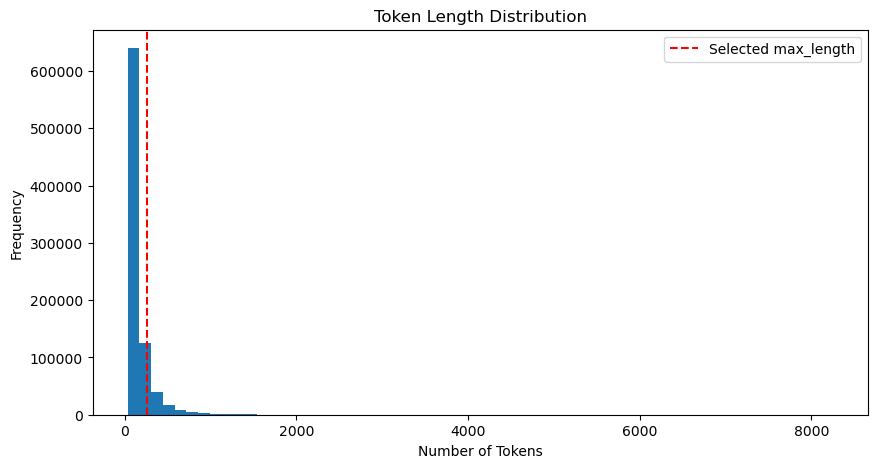

In [14]:
plt.figure(figsize=(10, 5))

plt.hist(
    token_lengths,
    bins=60,
)
plt.axvline(256, color="red", linestyle="--", label="Selected max_length")

plt.legend()

plt.title("Token Length Distribution")

plt.xlabel("Number of Tokens")

plt.ylabel("Frequency")

plt.show()

In [15]:
long_review = train_df[token_lengths > 512].iloc[0]["reviewText"]

In [16]:
encoding = tokenizer(
    long_review,
    max_length=512,
    truncation=True,
)

In [17]:
len(encoding["input_ids"])

512

In [18]:
for idx in [0, 1, 2]:
    text = train_df.loc[idx, "reviewText"]
    tokens = tokenizer.tokenize(text)
    print("=" * 80)
    print(text[:200])
    print()
    print(tokens[:50])

I have an older URC-WR7 remote and thought this would be an upgrade (and because TWC stuck me with it), but this one fails where the other one didn't.  The old remote could go head to head and learn. 

['i', 'have', 'an', 'older', 'ur', '##c', '-', 'wr', '##7', 'remote', 'and', 'thought', 'this', 'would', 'be', 'an', 'upgrade', '(', 'and', 'because', 't', '##wc', 'stuck', 'me', 'with', 'it', ')', ',', 'but', 'this', 'one', 'fails', 'where', 'the', 'other', 'one', 'didn', "'", 't', '.', 'the', 'old', 'remote', 'could', 'go', 'head', 'to', 'head', 'and', 'learn']
First time I've EVER had a remote that needed no programming whatsoever so I have to give it bragging rights.  All the other 8780Ls I've had certainly had to be set up first.

Yes I wish it was Silver

['first', 'time', 'i', "'", 've', 'ever', 'had', 'a', 'remote', 'that', 'needed', 'no', 'programming', 'whatsoever', 'so', 'i', 'have', 'to', 'give', 'it', 'bragg', '##ing', 'rights', '.', 'all', 'the', 'other', '87', '##80', '##l

## Selected Maximum Sequence Length

Based on the token length distribution:

- 90% percentile = ...
- 95% percentile = ...
- 99% percentile = ...

A maximum sequence length of **256** (or **384** یا **512** بسته به نتایج واقعی) was selected because it balances computational cost and information retention.